In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [8]:
df = pd.read_csv(
    "sales_forecasting_data.csv",
    parse_dates=["date"]
)

df.head()

,date,store_id,sales,promotion,holiday,weekday
0,2020-01-01,3,114.90,0,0,2
1,2020-02-01,1,101.25,1,0,3
2,2020-03-01,3,130.17,0,0,4
3,2020-04-01,1,161.68,0,0,5
4,2020-05-01,3,114.07,0,0,6


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 6


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[us]
 1   store_id   1000 non-null   int64         
 2   sales      1000 non-null   float64       
 3   promotion  1000 non-null   int64         
 4   holiday    1000 non-null   int64         
 5   weekday    1000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 47.0 KB


In [11]:
df.describe()

,date,store_id,sales,promotion,holiday,weekday
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000
mean,2021-05-19 06:37:26.400000,1.976000,300.635960,0.308000,0.087000,3.002
min,2020-01-01 00:00:00,1.000000,17.650000,0.000000,0.000000,0.000
25%,2020-09-06 18:00:00,1.000000,200.195000,0.000000,0.000000,1.000
50%,2021-05-14 12:00:00,2.000000,298.905000,0.000000,0.000000,3.000
75%,2022-01-22 06:00:00,3.000000,397.665000,1.000000,0.000000,5.000
max,2022-12-09 00:00:00,3.000000,571.140000,1.000000,1.000000,6.000
std,NaN,0.808751,123.745518,0.461898,0.281976,2.001


In [12]:
df.isnull().sum()

date         0
store_id     0
sales        0
promotion    0
holiday      0
weekday      0
dtype: int64

In [13]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [14]:
print("Stores:", df["store_id"].unique())
print("Number of stores:", df["store_id"].nunique())

Stores: [3 1 2]
Number of stores: 3


In [15]:
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,store_id,sales,promotion,holiday,weekday
0,2020-01-01,3,114.90,0,0,2
1,2020-01-02,2,169.90,0,0,5
2,2020-01-03,3,95.97,0,0,6
3,2020-01-04,3,181.02,0,0,2
4,2020-01-05,1,99.23,1,1,4


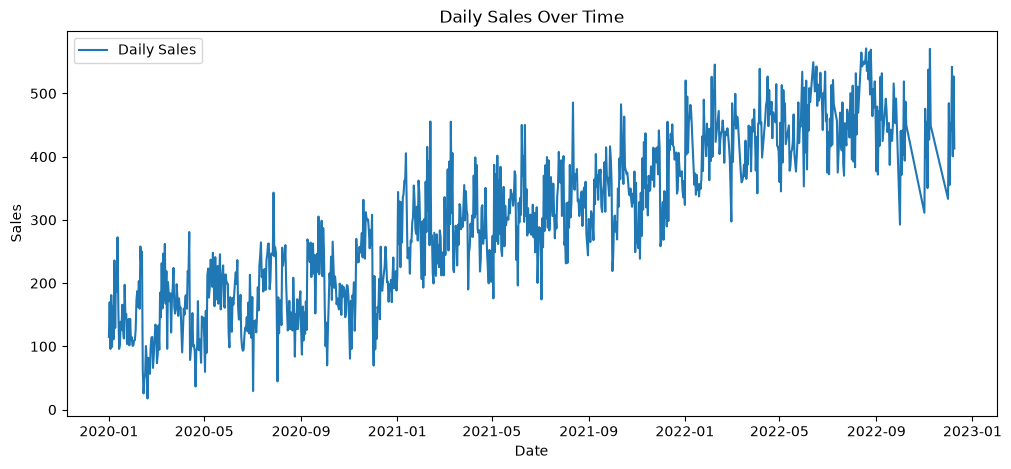

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["sales"],
    label="Daily Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales Over Time")

plt.legend()
plt.show()

In [17]:

store_sales = df.groupby("store_id")["sales"].sum()

store_sales

store_id
1    102250.73
2    104461.54
3     93923.69
Name: sales, dtype: float64

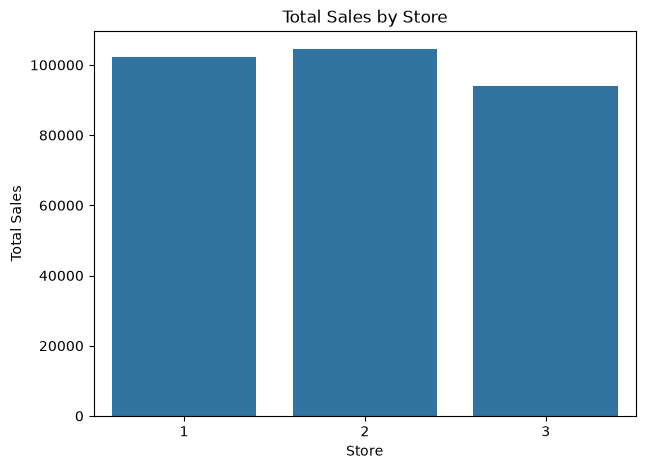

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values
)

plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title("Total Sales by Store")

plt.show()

In [19]:
average_store_sales = df.groupby("store_id")["sales"].mean()

average_store_sales

store_id
1    301.624572
2    301.911965
3    298.170444
Name: sales, dtype: float64

In [20]:
weekday_sales = df.groupby("weekday")["sales"].mean()

weekday_sales

weekday
0    301.540559
1    303.158239
2    301.895524
3    301.581189
4    296.396364
5    301.883846
6    298.013636
Name: sales, dtype: float64

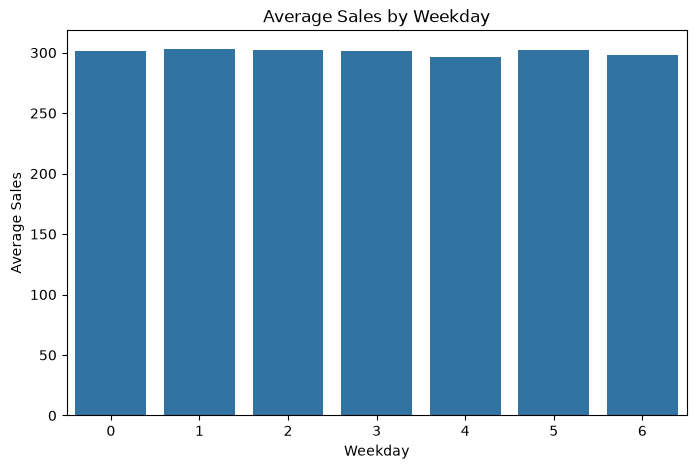

In [21]:

plt.figure(figsize=(8, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.xlabel("Weekday")
plt.ylabel("Average Sales")
plt.title("Average Sales by Weekday")

plt.show()

In [22]:
monthly_sales = (
    df.set_index("date")["sales"]
    .resample("ME")
    .sum()
)

monthly_sales.head()

date
2020-01-31    4445.66
2020-02-29    3379.37
2020-03-31    5189.28
2020-04-30    3992.36
2020-05-31    5919.90
Freq: ME, Name: sales, dtype: float64

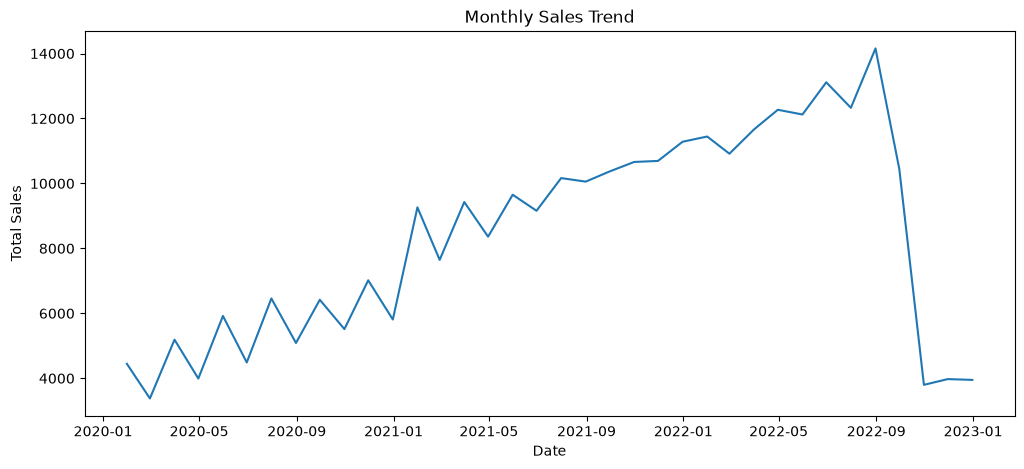

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")

plt.show()

In [24]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
    .sort_index()
)

daily_sales.head()

date
2020-01-01    114.90
2020-01-02    169.90
2020-01-03     95.97
2020-01-04    181.02
2020-01-05     99.23
Name: sales, dtype: float64

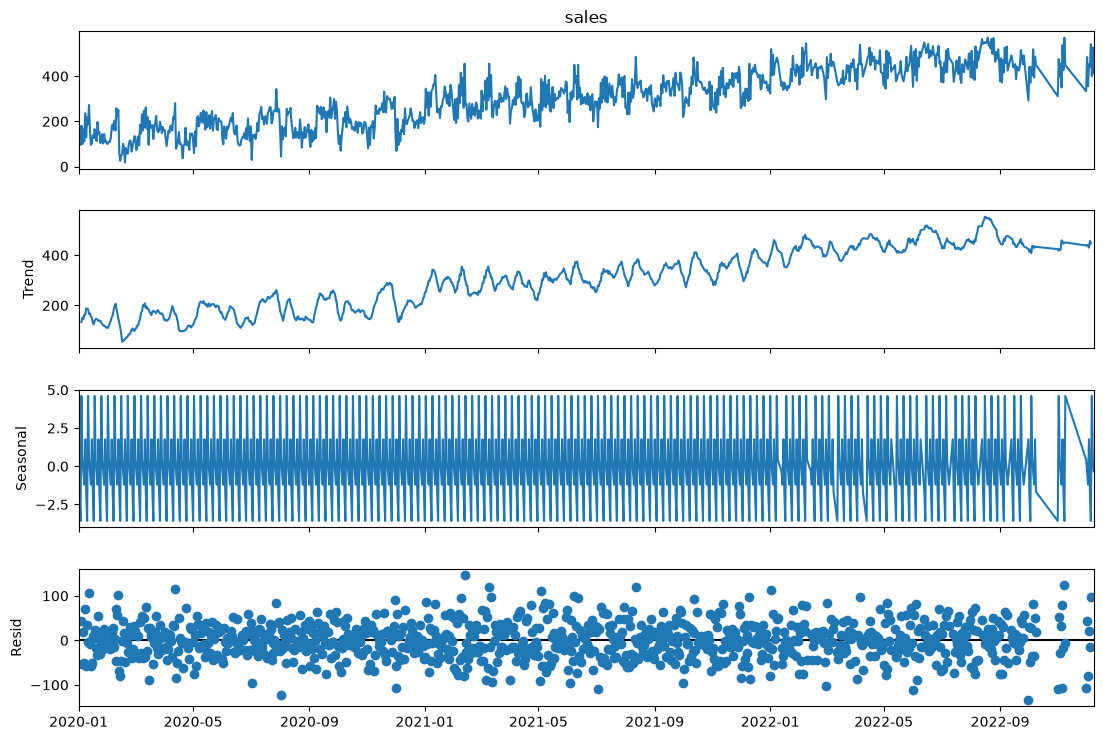

In [28]:
decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.show()

In [29]:
promotion_sales = (
    df.groupby("promotion")["sales"]
    .mean()
)

promotion_sales

promotion
0    300.108613
1    301.820779
Name: sales, dtype: float64

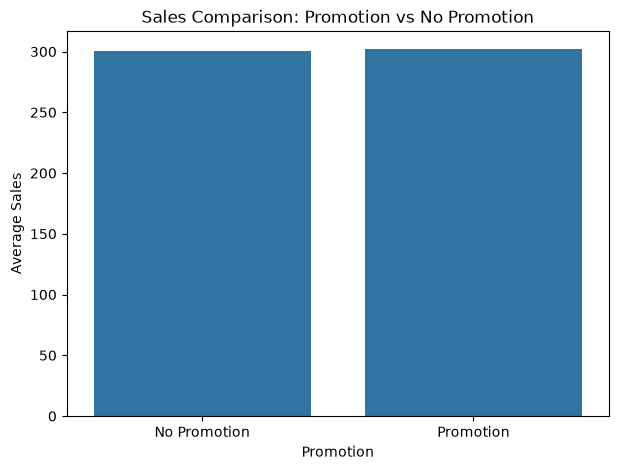

In [30]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=promotion_sales.index,
    y=promotion_sales.values
)

plt.xticks(
    [0, 1],
    ["No Promotion", "Promotion"]
)

plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.title("Sales Comparison: Promotion vs No Promotion")

plt.show()

In [31]:
holiday_sales = (
    df.groupby("holiday")["sales"]
    .mean()
)

holiday_sales

holiday
0    299.990033
1    307.414483
Name: sales, dtype: float64

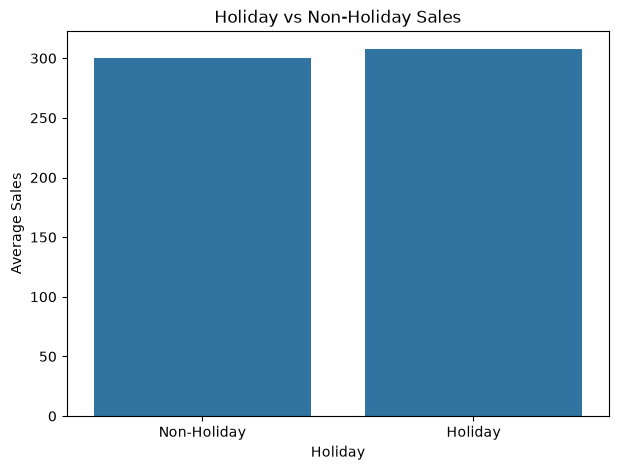

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.xticks(
    [0, 1],
    ["Non-Holiday", "Holiday"]
)

plt.xlabel("Holiday")
plt.ylabel("Average Sales")
plt.title("Holiday vs Non-Holiday Sales")

plt.show()

In [33]:
df["moving_average_30"] = (
    df["sales"].rolling(window=30).mean()
)

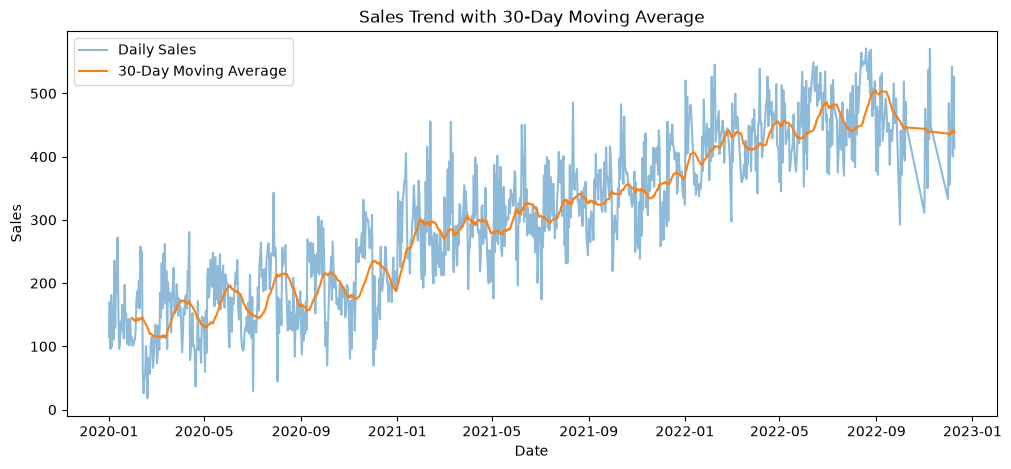

In [34]:

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["sales"],
    label="Daily Sales",
    alpha=0.5
)

plt.plot(
    df["date"],
    df["moving_average_30"],
    label="30-Day Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Trend with 30-Day Moving Average")

plt.legend()
plt.show()

In [35]:

df["rolling_std"] = (
    df["sales"].rolling(window=30).std()
)

df[["date", "sales", "rolling_std"]].tail()

,date,sales,rolling_std
995,2022-12-05,441.86,65.530564
996,2022-12-06,542.10,68.296720
997,2022-12-07,400.58,68.628311
998,2022-12-08,526.93,70.455070
999,2022-12-09,412.88,69.227036


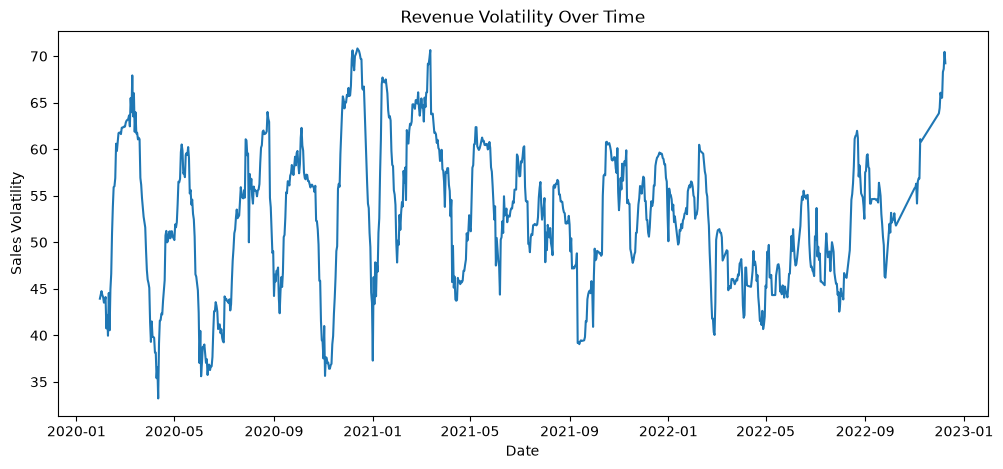

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["rolling_std"]
)

plt.xlabel("Date")
plt.ylabel("Sales Volatility")
plt.title("Revenue Volatility Over Time")

plt.show()

In [37]:
sales_data = (
    df.groupby("date")["sales"]
    .sum()
    .sort_index()
)

sales_data.head()

date
2020-01-01    114.90
2020-01-02    169.90
2020-01-03     95.97
2020-01-04    181.02
2020-01-05     99.23
Name: sales, dtype: float64

In [38]:

train_size = int(len(sales_data) * 0.8)

train = sales_data.iloc[:train_size]
test = sales_data.iloc[train_size:]

print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 800
Testing records: 200


In [39]:
model = ARIMA(
    train,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  800
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4241.211
Date:                Mon, 10 Aug 2026   AIC                           8488.422
Time:                        15:37:38   BIC                           8502.472
Sample:                             0   HQIC                          8493.820
                                - 800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5583      0.046    -12.188      0.000      -0.648      -0.469
ma.L1         -0.0746      0.055     -1.364      0.173      -0.182       0.033
sigma2      2387.0305     97.339     24.523      0.0

In [40]:

forecast = model_fit.forecast(
    steps=len(test)
)

forecast.head()

800    390.801724
801    410.068109
802    399.311455
803    405.317024
804    401.964043
Name: predicted_mean, dtype: float64

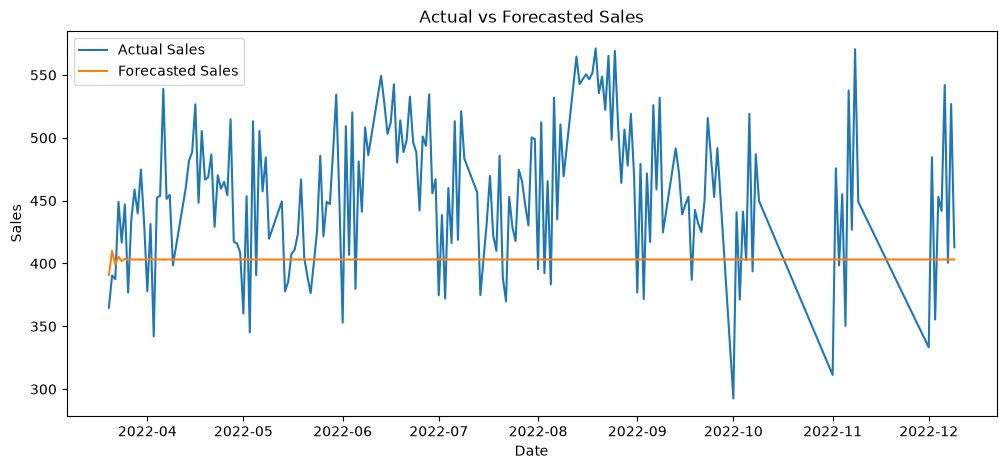

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual Sales"
)

plt.plot(
    test.index,
    forecast,
    label="Forecasted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Forecasted Sales")

plt.legend()
plt.show()

In [42]:
mae = mean_absolute_error(
    test,
    forecast
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 64.1998115570348


In [43]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 77.20151653010923


In [44]:
final_model = ARIMA(
    sales_data,
    order=(1, 1, 1)
)

final_model_fit = final_model.fit()

In [45]:
future_forecast = final_model_fit.forecast(
    steps=30
)

future_forecast

1000    482.182442
1001    442.442188
1002    465.230531
1003    452.162961
1004    459.656326
1005    455.359389
1006    457.823391
1007    456.410453
1008    457.220677
1009    456.756069
1010    457.022490
1011    456.869715
1012    456.957321
1013    456.907085
1014    456.935892
1015    456.919374
1016    456.928846
1017    456.923414
1018    456.926529
1019    456.924743
1020    456.925767
1021    456.925180
1022    456.925517
1023    456.925323
1024    456.925434
1025    456.925371
1026    456.925407
1027    456.925386
1028    456.925398
1029    456.925391
Name: predicted_mean, dtype: float64

In [46]:

future_dates = pd.date_range(
    start=sales_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_dates

DatetimeIndex(['2022-12-10', '2022-12-11', '2022-12-12', '2022-12-13',
               '2022-12-14', '2022-12-15', '2022-12-16', '2022-12-17',
               '2022-12-18', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31', '2023-01-01', '2023-01-02',
               '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-07', '2023-01-08'],
              dtype='datetime64[us]', freq='D')

In [47]:
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_forecast.values
})

forecast_df.head()

,date,forecast_sales
0,2022-12-10,482.182442
1,2022-12-11,442.442188
2,2022-12-12,465.230531
3,2022-12-13,452.162961
4,2022-12-14,459.656326


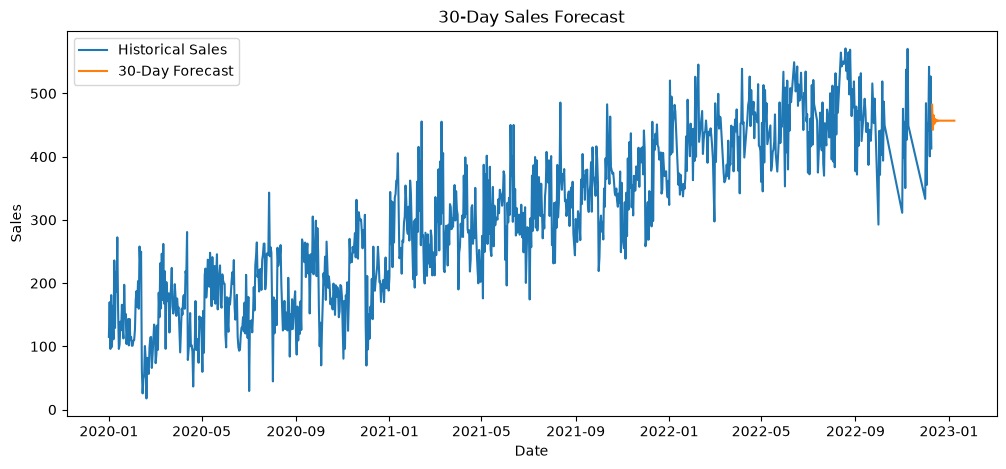

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(
    sales_data.index,
    sales_data.values,
    label="Historical Sales"
)

plt.plot(
    future_dates,
    future_forecast,
    label="30-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("30-Day Sales Forecast")

plt.legend()
plt.show()

In [49]:
store_forecasts = []

for store in sorted(df["store_id"].unique()):

    print("Forecasting Store:", store)

    store_data = (
        df[df["store_id"] == store]
        .groupby("date")["sales"]
        .sum()
        .sort_index()
    )

    train_size = int(len(store_data) * 0.8)

    train_store = store_data.iloc[:train_size]
    test_store = store_data.iloc[train_size:]

    model = ARIMA(
        train_store,
        order=(1, 1, 1)
    )

    model_fit = model.fit()

    store_forecast = model_fit.forecast(
        steps=len(test_store)
    )
    mae_store = mean_absolute_error(
        test_store,
        store_forecast
    )

    rmse_store = np.sqrt(
        mean_squared_error(
            test_store,
            store_forecast
        )
    )

    print("MAE:", mae_store)
    print("RMSE:", rmse_store)
    print()

Forecasting Store: 1
MAE: 53.08788052157214
RMSE: 64.23765940508979

Forecasting Store: 2
MAE: 56.70165702357433
RMSE: 68.6419987268966

Forecasting Store: 3
MAE: 63.112348530280556
RMSE: 77.30100508628868



In [50]:
store_forecast_results = []

for store in sorted(df["store_id"].unique()):

    store_data = (
        df[df["store_id"] == store]
        .groupby("date")["sales"]
        .sum()
        .sort_index()
    )

    final_store_model = ARIMA(
        store_data,
        order=(1, 1, 1)
    )

    final_store_fit = final_store_model.fit()

    future_store_forecast = final_store_fit.forecast(
        steps=30
    )

    future_store_dates = pd.date_range(
        start=store_data.index.max() + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )
    temp = pd.DataFrame({
        "date": future_store_dates,
        "store_id": store,
        "forecast_sales": future_store_forecast.values
    })

    store_forecast_results.append(temp)

store_forecast_df = pd.concat(
    store_forecast_results,
    ignore_index=True
)

store_forecast_df.head()

,date,store_id,forecast_sales
0,2022-12-06,1,435.002500
1,2022-12-07,1,433.055207
2,2022-12-08,1,432.502243
3,2022-12-09,1,432.345220
4,2022-12-10,1,432.300631


In [51]:
forecast_df.to_csv(
    "sales_forecast.csv",
    index=False
)

print("sales_forecast.csv saved successfully.")

sales_forecast.csv saved successfully.


In [52]:
store_forecast_df.to_csv(
    "store_forecast.csv",
    index=False
)

print("store_forecast.csv saved successfully.")

store_forecast.csv saved successfully.


In [53]:
df.to_csv(
    "sales_analysis_data.csv",
    index=False
)

print("sales_analysis_data.csv saved successfully.")

sales_analysis_data.csv saved successfully.
